In [2]:
# Exercise 2.1: Generate 200 fake "brown dwarfs": temperatures uniform in [300, 1300] K, radii uniform in [0.6, 1.3] R_Jup, using np.random. No loops allowed.
import numpy as np

dwarf_temps = np.random.uniform(low=300, high=1300, size=200)
dwarf_radii = np.random.uniform(low=0.6, high=1.3, size=200)

full_data = np.column_stack((dwarf_temps, dwarf_radii))


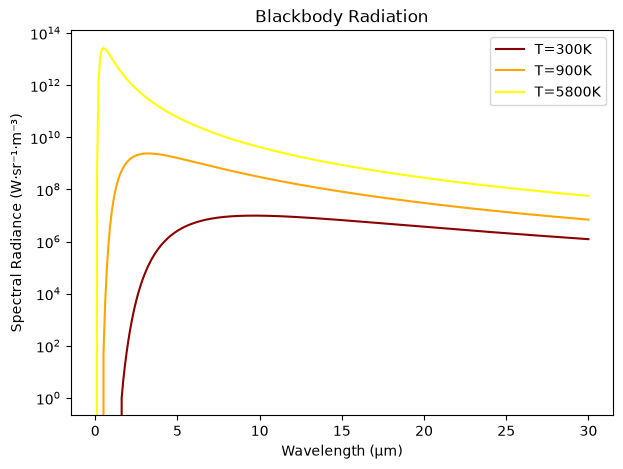

In [3]:
import numpy as np
import math as math
import matplotlib.pyplot as plt


def law_planck(wavelength, T: int):
    #constants needed
    kb = 1.380649E-23 # J-K
    c = 299792458 # m/s
    h = 6.62607015E-34 # J-s

    if wavelength == 0:
        return 0
    section1 = (2 * h * c**2) / (wavelength**5)
    pre_exponent = (h * c) / (wavelength * kb * T)
    section2 = np.exp(pre_exponent) - 1
    if section2 == 0:
        return 0
    return section1 / section2

wavelengths = np.linspace(0, 30E-6, 300)

profile_300 = np.vectorize(lambda x: law_planck(x, 300))(np.copy(wavelengths))
profile_900 = np.vectorize(lambda x: law_planck(x, 900))(np.copy(wavelengths))
profile_5800 = np.vectorize(lambda x: law_planck(x, 5800))(np.copy(wavelengths))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wavelengths * 1E6, profile_300, label='T=300K', color="darkred")
ax.plot(wavelengths * 1E6, profile_900, label='T=900K', color="orange")
ax.plot(wavelengths * 1E6, profile_5800, label='T=5800K', color="yellow")

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Spectral Radiance (W·sr⁻¹·m⁻³)")
ax.set_title("Blackbody Radiation")
ax.set_yscale("log")
ax.legend()
fig.savefig("spectrum.png", dpi=200)

In [1]:
# Doing the species example 
from species import SpeciesInit
from species.data.database import Database
from species.read.read_color import ReadColorMagnitude
from species.plot.plot_color import plot_color_magnitude

SpeciesInit()

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/sprint-week

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/sprint-week/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


In [2]:
database = Database()
database.add_photometry('vlm-plx')
database.add_companion('51 Eri b', verbose=False)
database.add_companion('beta Pic b', verbose=False)
database.add_companion('PZ Tel B', verbose=False)



-----------------------
Add photometric library
-----------------------

Database tag: vlm-plx
Library: Database of Ultracool Parallaxes
Add companion: ['51 Eri b']
Add companion: ['beta Pic b']
Add companion: ['PZ Tel B']


/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/data/database.py:1525: UserWarning: Found 33 fluxes with NaN in the data of GPI_YJHK. Removing the spectral fluxes that contain a NaN.
  warnings.warn(


In [3]:
colormag = ReadColorMagnitude(library='vlm-plx', filters_color=('MKO/NSFCam.J', 'MKO/NSFCam.H'), filter_mag='MKO/NSFCam.J')


--------------------
Read color-magnitude
--------------------

Database tag: vlm-plx
Library type: phot_lib
Filters color: ('MKO/NSFCam.J', 'MKO/NSFCam.H')
Filter magnitude: MKO/NSFCam.J


In [4]:
colorbox = colormag.get_color_magnitude(object_type='field')


-------------------
Get color-magnitude
-------------------

Object type: field
Returning ColorMagBox with 241 objects



----------------------------
Plot color-magnitude diagram
----------------------------

Boxes:
   - ColorMagBox

Objects:
   - 51 Eri b: ('MKO/NSFCam.J', 'MKO/NSFCam.H', 'MKO/NSFCam.J')
   - beta Pic b: ('Paranal/NACO.J', 'Paranal/NACO.H', 'Paranal/NACO.J')
   - PZ Tel B: ('Paranal/NACO.J', 'Paranal/NACO.H', 'Paranal/NACO.J')

Spectral range: ('late M', 'late T')
Companion labels: True
Accretion markers: False

Mass labels: None
Teff labels: None

Reddening:
   - (('MKO/NSFCam.J', 'MKO/NSFCam.H'), ('MKO/NSFCam.J', 1.0), 'MgSiO3', 0.1, (-0.8, 10.0))

Figure size: (4.0, 4.8)
Limits x axis: (-1.2, 1.5)
Limits y axis: (21.0, 8.0)


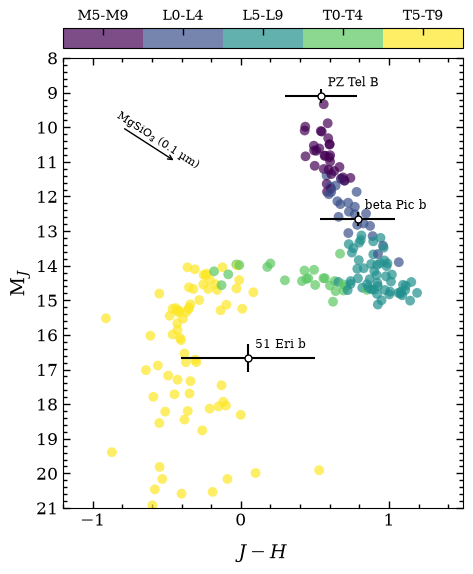

In [7]:
objects = [('51 Eri b', 'MKO/NSFCam.J', 'MKO/NSFCam.H', 'MKO/NSFCam.J'),
           ('beta Pic b', 'Paranal/NACO.J', 'Paranal/NACO.H', 'Paranal/NACO.J'),
           ('PZ Tel B', 'Paranal/NACO.J', 'Paranal/NACO.H', 'Paranal/NACO.J')]
fig = plot_color_magnitude(boxes=[colorbox, ],
                           objects=objects,
                           reddening=[(('MKO/NSFCam.J', 'MKO/NSFCam.H'), ('MKO/NSFCam.J', 1.), 'MgSiO3', 0.1, (-0.8, 10.))],
                           label_x=r'$J - H$',
                           label_y=r'M$_J$',
                           xlim=(-1.2, 1.5),
                           ylim=(21., 8.),
                           offset=(-0.08, -0.08),
                           companion_labels=True,
                           field_range=('late M', 'late T'),
                           legend=None,
                           output=None)